# <u>Water Potability

- Water is one of the most essential resources for life, and its quality directly impacts human health, ecosystems, and industrial processes.
- Ensuring access to clean and safe drinking water is a global priority, as contaminated water can lead to serve health issues, pollution, climate change, and population growth, monitoring and predicting water quality has become more critical than ever.
- Water potability refers to the safety of water for human consumption.
- Potablewater is free from harmful contaminants and bacteria and is safe for drinking and food preparation.
- The World Health Organization considers access to safe drinking water a basic human right.
- There are various methods to ensure water potability, including filteration nad treatment processes such as UV filteration and reverse osmosis.
- In developed countries, tap water meets drinking water quality standards, although only a samll proportion is actually consumed or used in food preparation.
- If you are concerned about the potability of your water, you can have it tested by a professional laboratory.
- A water potability test is a crucial evaluation of water quality that determines its suitability for human consumption. 

# <u>Objective
- The goal of this project is to develop a machine learning model that can predict the potability of water based on the provided key features.

The target variable is binary:
- 1: Potable (safe to drink)
- 0: Non-potable (unsafe to drink)

<u>This is a binary classification problem

## Dataset Features:

- `pH`: Measure of acidity or alkalinity( pH < 6.5 → acidic water may corrode pipes metallic taste pH > 8.5 → alkaline/basic water bitter taste mineral deposits).
- `Hardness`: Concentration of calcium and magnesium icons.
- `Solids`: Total dissolved solids in water(TDS).
- `Chloramines`: Amount of chloramines in water.
- `Sulfate`: Amount of sulfate in water.
- `Conductivity`: Electrical conductivity of water.
- `Organic_carbon`: Amount of organic carbon in water.
- `Trihalomethanes`: Amount if trihalomethanes in water.
- `Turbidity`: Measure of water clarity.
- `Potability`: Target variable(1 = Potable, 0 = Not potable)

## Importing Basic Libraries

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Load the Dataset
df = pd.read_csv('water_potability.csv', encoding='latin-1')
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.8904555,20791.31898,7.300211873,368.516441,564.3086542,10.37978308,86.99097046,2.963135381,0
1,3.716080075,129.4229205,18630.05786,6.635245884,NaN,592.8853591,15.18001312,56.32907628,4.500656275,0
2,8.099124189,224.2362594,19909.54173,9.275883603,NaN,418.6062131,16.86863693,66.42009251,3.05593375,0
3,8.316765884,214.3733941,22018.41744,8.059332377,356.886136,363.2665162,18.4365245,100.3416744,4.628770537,0
4,9.092223456,181.1015092,17978.98634,6.546599974,310.135738,398.4108134,11.55827944,31.99799273,4.075075425,0


In [6]:
# Features of the dataset
df.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [8]:
# Check shape of dataset
df.shape

(3276, 10)

In [10]:
# Data Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   object 
 1   Hardness         3276 non-null   object 
 2   Solids           3276 non-null   object 
 3   Chloramines      3276 non-null   object 
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   object 
 6   Organic_carbon   3276 non-null   object 
 7   Trihalomethanes  3114 non-null   object 
 8   Turbidity        3276 non-null   object 
 9   Potability       3276 non-null   int64  
dtypes: float64(1), int64(1), object(8)
memory usage: 256.1+ KB


In [12]:
# In this dataset columns like ph, Hardness, Solids, Chloramines, Conductivity, Organic_carbon, Trihalomethanes, Turbity these all are in object format, which should be numerical so we need convert these into numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [14]:
# Check datatypes of columns
df.dtypes

ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

In [16]:
# Check duplicate dataset
df.duplicated().sum()

0

In [18]:
# Check missing data
print(df.isnull().sum())
print()
print(f"The total no of missing values are : {df.isnull().sum().sum()}")

ph                 492
Hardness             2
Solids              11
Chloramines          2
Sulfate            781
Conductivity         2
Organic_carbon      63
Trihalomethanes    163
Turbidity            2
Potability           0
dtype: int64

The total no of missing values are : 1518


In [20]:
# Check percent of missing data
(df.isnull().sum()/len(df)*100).round(3)

ph                 15.018
Hardness            0.061
Solids              0.336
Chloramines         0.061
Sulfate            23.840
Conductivity        0.061
Organic_carbon      1.923
Trihalomethanes     4.976
Turbidity           0.061
Potability          0.000
dtype: float64

## Handling the missing value

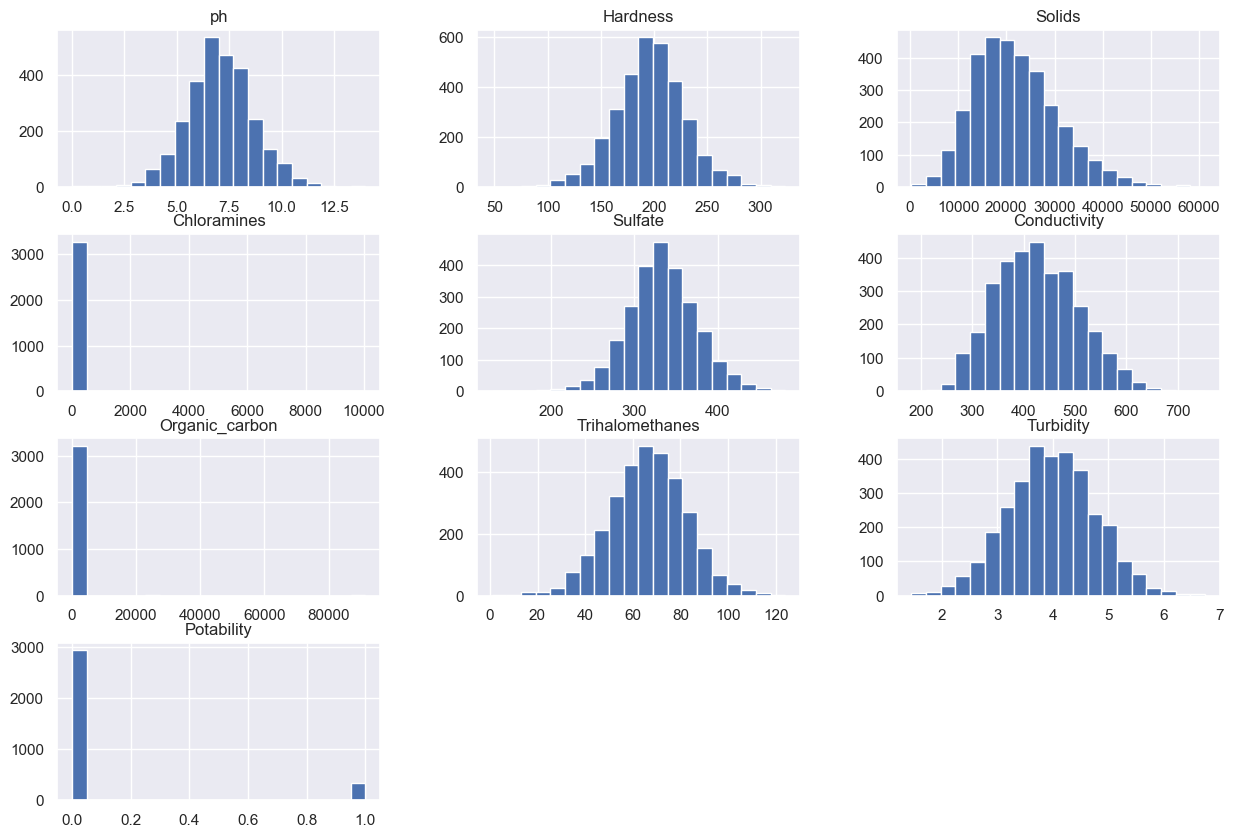

In [22]:
df.hist(figsize= (15,10), bins=20)
plt.show()

In [26]:
df.describe().round(3)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2784.000,3274.000,3265.000,3274.000,2495.000,3274.000,3213.000,3113.000,3274.000,3276.000
mean,7.081,196.360,22015.793,10.189,333.776,426.207,50.532,66.395,3.967,0.103
std,1.595,32.887,8777.206,175.473,41.417,80.811,1672.223,16.177,0.781,0.304
min,0.000,47.432,320.943,-4.502,129.000,181.484,2.200,0.738,1.450,0.000
25%,6.093,176.844,15658.086,6.130,307.699,365.763,12.079,55.836,3.440,0.000
50%,7.036,196.928,20933.513,7.132,333.074,421.885,14.226,66.621,3.955,0.000
75%,8.062,216.672,27336.963,8.116,359.950,481.763,16.563,77.340,4.501,0.000
max,14.000,323.124,61227.196,10047.050,481.031,753.343,91456.654,124.000,6.739,1.000


In [28]:
# Missing value Imputation
# Filling missing values by median
df['ph'] = df['ph'].fillna(df['ph'].median())
df['Hardness'] = df['Hardness'].fillna(df['Hardness'].median())
df['Solids'] = df['Solids'].fillna(df['Solids'].median())
df['Chloramines'] = df['Chloramines'].fillna(df['Chloramines'].median())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].median())
df['Conductivity'] = df['Conductivity'].fillna(df['Conductivity'].median())
df['Organic_carbon'] = df['Organic_carbon'].fillna(df['Organic_carbon'].median())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].median())
df['Turbidity'] = df['Turbidity'].fillna(df['Turbidity'].median())

In [30]:
# Check missing values
print(df.isnull().sum())
print()
print(f"The total no of missing values are {df.isnull().sum().sum()}")

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

The total no of missing values are 0


## Check for Correlation

In [32]:
df.corr().round(3)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
ph,1.000,0.076,-0.082,-0.017,0.014,0.018,-0.030,0.003,-0.036,-0.002
Hardness,0.076,1.000,-0.048,-0.043,-0.093,-0.024,0.030,-0.013,-0.014,-0.007
Solids,-0.082,-0.048,1.000,0.022,-0.150,0.013,0.021,-0.009,0.020,0.022
Chloramines,-0.017,-0.043,0.022,1.000,-0.017,0.017,-0.000,-0.020,0.004,-0.006
Sulfate,0.014,-0.093,-0.150,-0.017,1.000,-0.014,0.015,-0.026,-0.010,0.018
Conductivity,0.018,-0.024,0.013,0.017,-0.014,1.000,-0.030,0.000,0.006,0.014
Organic_carbon,-0.030,0.030,0.021,-0.000,0.015,-0.030,1.000,-0.001,0.002,-0.007
Trihalomethanes,0.003,-0.013,-0.009,-0.020,-0.026,0.000,-0.001,1.000,-0.022,-0.021
Turbidity,-0.036,-0.014,0.020,0.004,-0.010,0.006,0.002,-0.022,1.000,-0.016
Potability,-0.002,-0.007,0.022,-0.006,0.018,0.014,-0.007,-0.021,-0.016,1.000


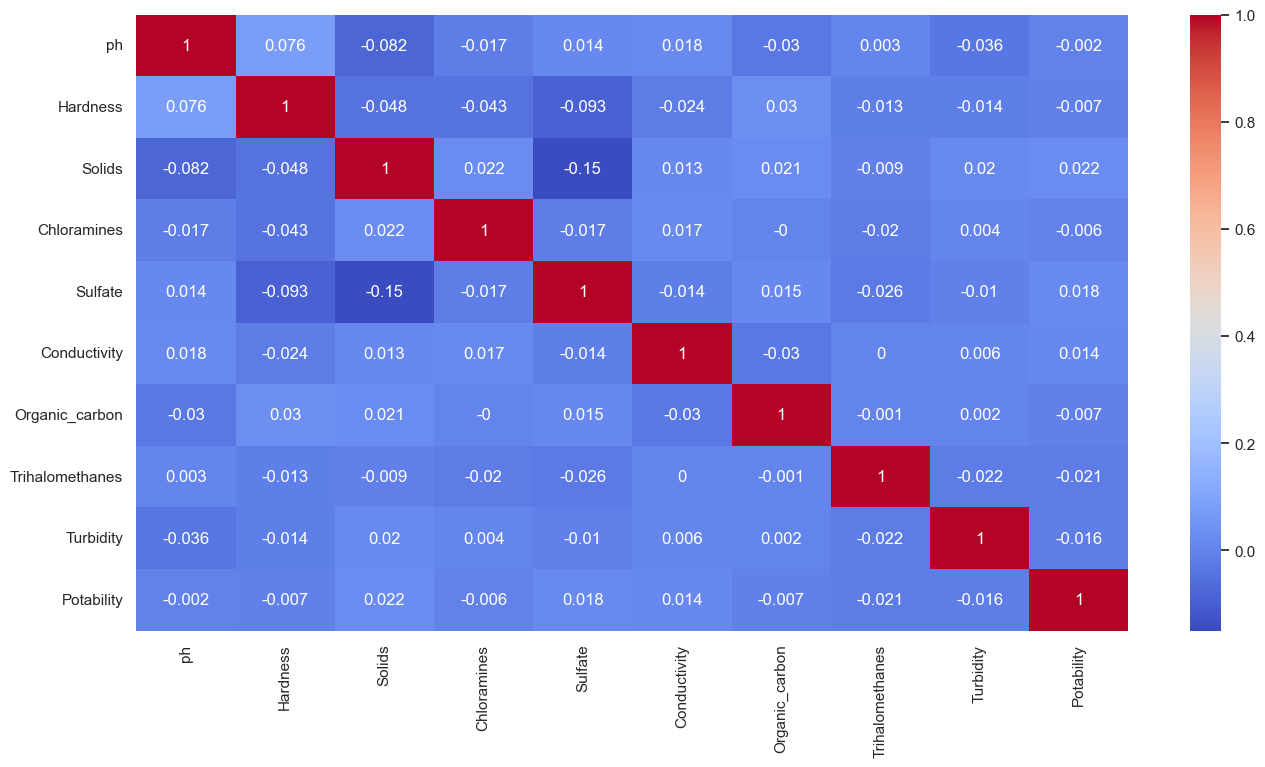

In [34]:
# Check correlation with heatmap
plt.figure(figsize=(16,8))
sns.heatmap(df.corr().round(3), annot=True, cmap='coolwarm')
plt.show()

## Outlier Treatment

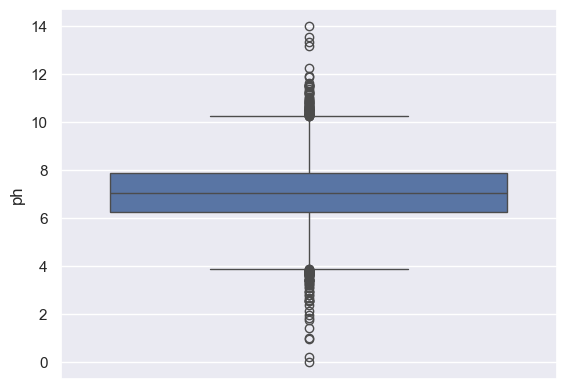

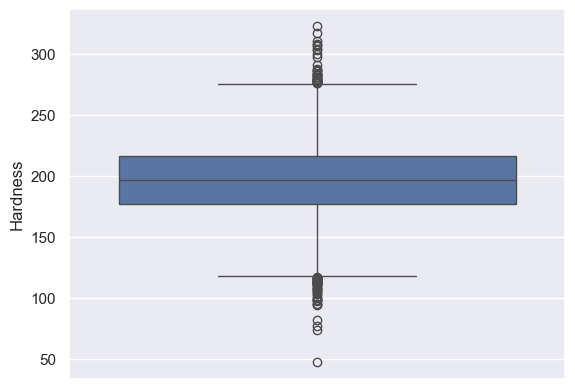

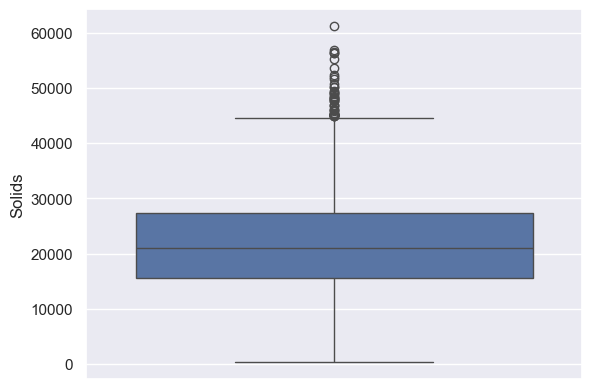

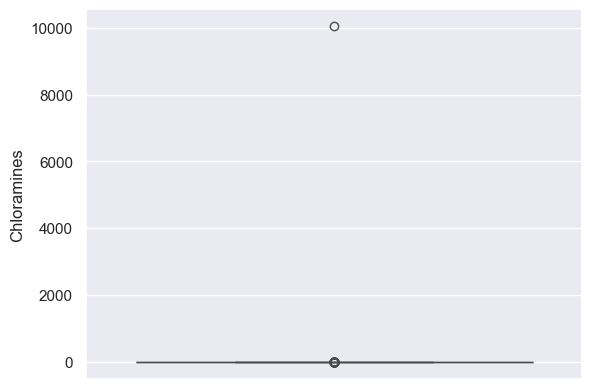

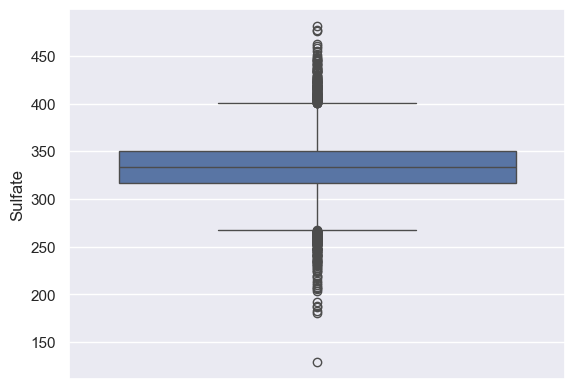

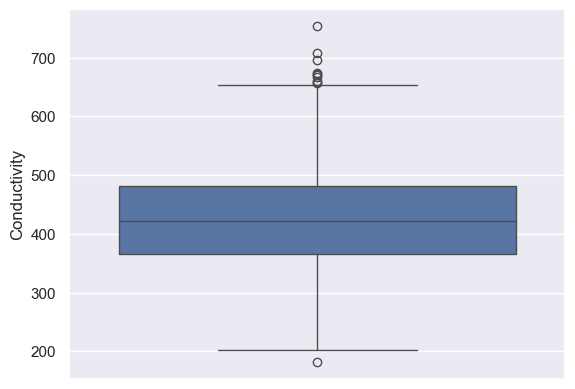

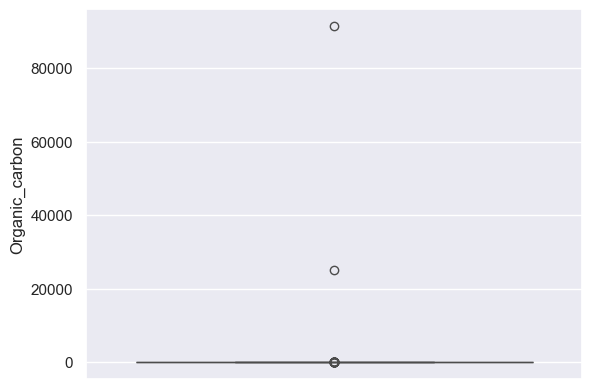

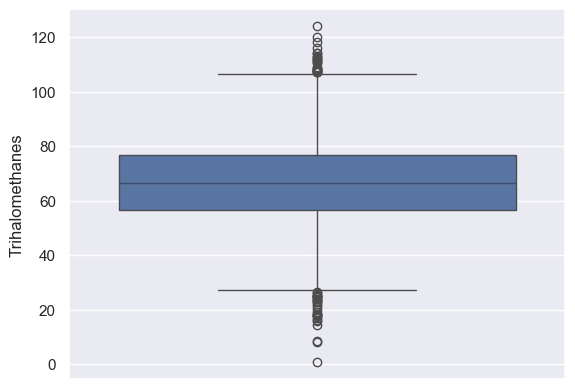

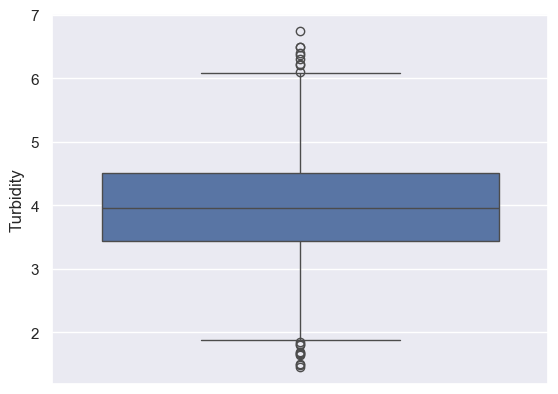

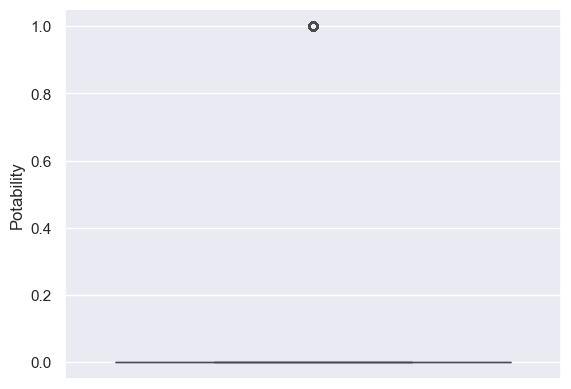

In [36]:
# Checking outlier
def boxplots(col):
    sns.boxplot(df[col])
    plt.show()

for i in list(df.select_dtypes(exclude=['object']).columns)[0:]:
    boxplots(i)

In [38]:
# outlier checking 
df.skew()

ph                  0.041606
Hardness           -0.038578
Solids              0.623866
Chloramines        57.229287
Sulfate            -0.027278
Conductivity        0.264988
Organic_carbon     52.420207
Trihalomethanes    -0.087074
Turbidity          -0.008461
Potability          2.610286
dtype: float64

In [40]:
# Check total no.of Outlier in each Columns
num_cols = df.select_dtypes(include=['number'])

# Calculate Q1, Q3, IQR
Q1 = num_cols.quantile(0.25)
Q3 = num_cols.quantile(0.75)
IQR = Q3 - Q1

outliers = ((num_cols < (Q1 - 1.5 * IQR)) | (num_cols > (Q3 + 1.5 * IQR)))
outlier_count = outliers.sum()

print(outlier_count)

ph                 142
Hardness            83
Solids              47
Chloramines         61
Sulfate            264
Conductivity        11
Organic_carbon      34
Trihalomethanes     54
Turbidity           19
Potability         338
dtype: int64


In [42]:
num_cols = df.select_dtypes(include='number').drop('Potability', axis = 1).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower_limit, upper_limit)

In [44]:
# Check total no.of Outlier in each Columns
num_cols = df.select_dtypes(include=['number'])

# Calculate Q1, Q3, IQR
Q1 = num_cols.quantile(0.25)
Q3 = num_cols.quantile(0.75)
IQR = Q3 - Q1

outliers = ((num_cols < (Q1 - 1.5 * IQR)) | (num_cols > (Q3 + 1.5 * IQR)))
outlier_count = outliers.sum()

print(outlier_count)

ph                   0
Hardness             0
Solids               0
Chloramines          0
Sulfate              0
Conductivity         0
Organic_carbon       0
Trihalomethanes      0
Turbidity            0
Potability         338
dtype: int64


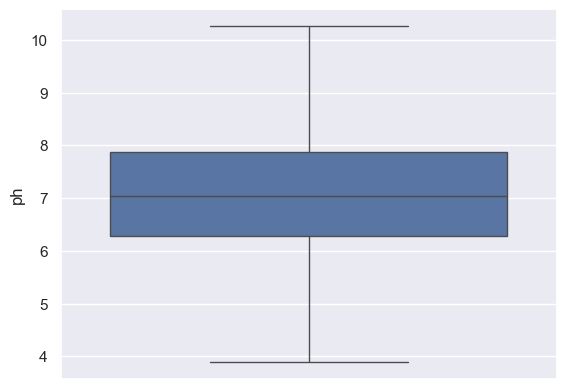

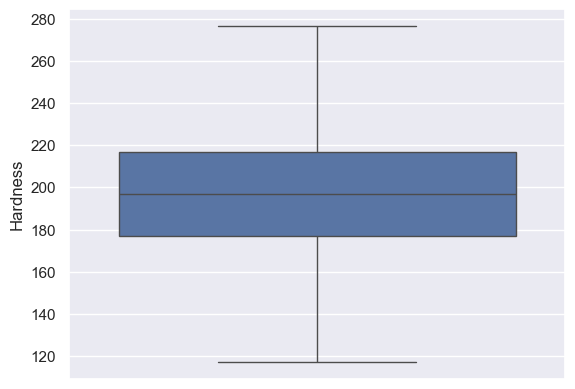

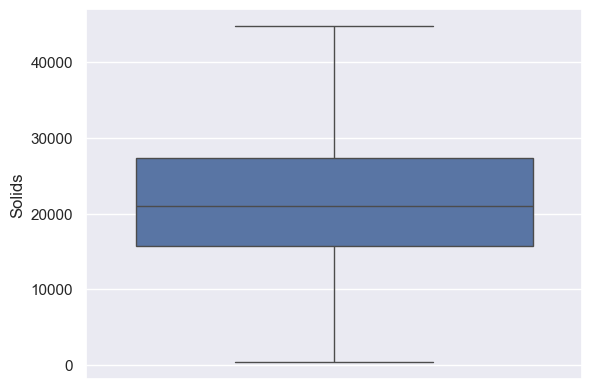

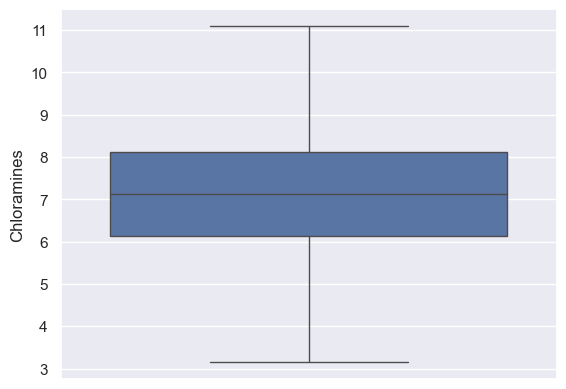

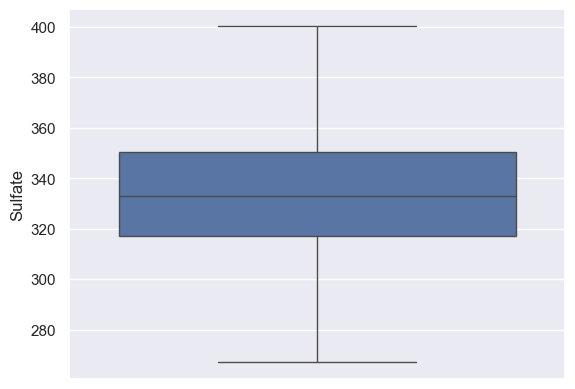

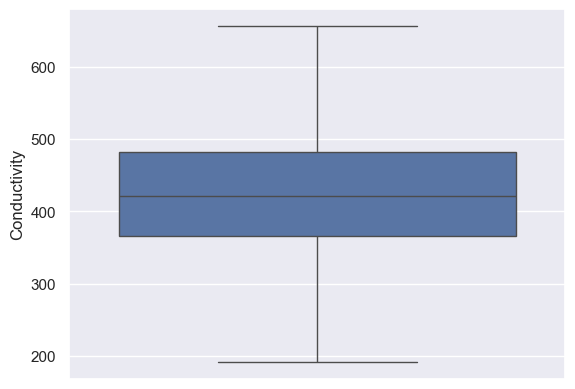

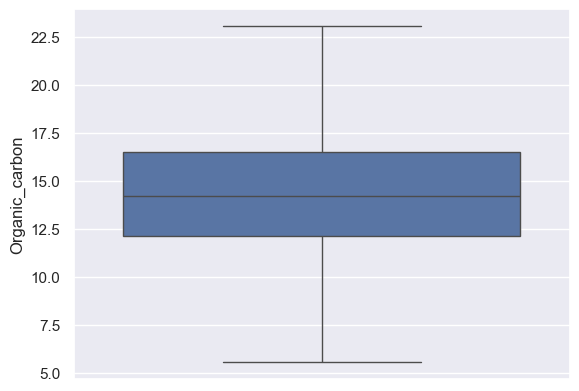

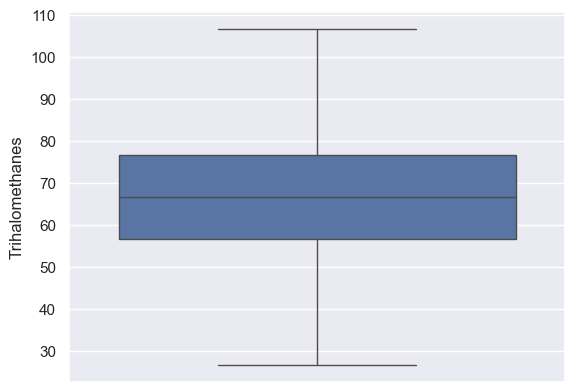

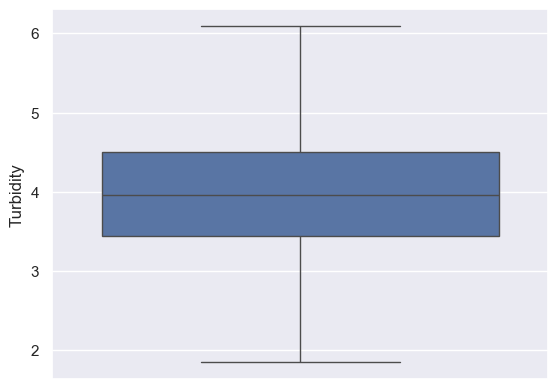

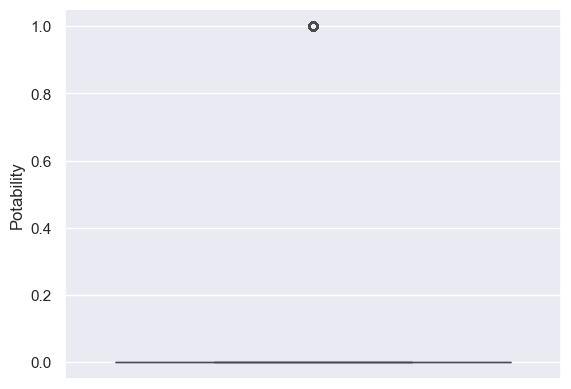

In [46]:
def boxplots(col):
    sns.boxplot(df[col])
    plt.show()

for i in list(df.select_dtypes(exclude=['object']).columns)[0:]:
    boxplots(i)

## Check the Target Variable

In [48]:
df['Potability'].value_counts()

Potability
0    2938
1     338
Name: count, dtype: int64

In [50]:
df['Potability'].value_counts(normalize=True)

Potability
0    0.896825
1    0.103175
Name: proportion, dtype: float64

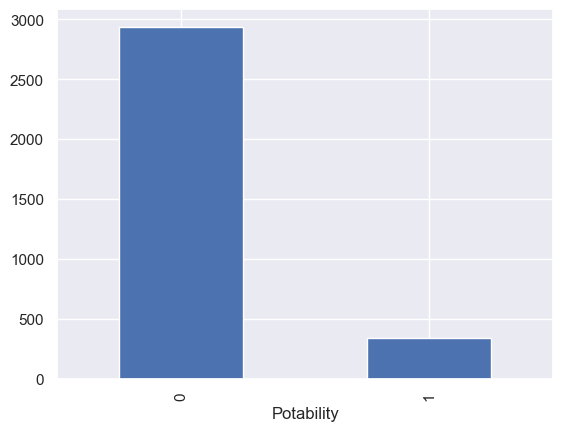

In [52]:
df['Potability'].value_counts().plot(kind = 'bar')
plt.show()

# Data Preprocessing

## Split Features and Target

In [54]:
# Separate independent and target variables
x = df.drop('Potability', axis = 1)
y = df['Potability'] 

In [56]:
x.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,7.035894,204.890456,20791.31898,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135
1,3.889107,129.422921,18630.05786,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656
2,8.099124,224.236259,19909.54173,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934
3,8.316766,214.373394,22018.41744,8.059332,356.886136,363.266516,18.436525,100.341674,4.628771
4,9.092223,181.101509,17978.98634,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075


In [58]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Potability, dtype: int64

In [60]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix
from imblearn.over_sampling import RandomOverSampler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

## Split Data into Train and test

In [61]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

## Feature scaling

In [64]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_sclaed = scaler.transform(x_test)

## Handle imbalance (Balancing the data)

In [66]:
from imblearn.over_sampling import SMOTE
smote =  SMOTE(random_state=42, k_neighbors=5)
x_train_bal, y_train_bal = smote.fit_resample(x_train_scaled, y_train)

print("Before SMOTE : ", y_train.value_counts().to_dict())
print()
print("After SMOTE : ", y_train_bal.value_counts().to_dict())

Before SMOTE :  {0: 2350, 1: 270}

After SMOTE :  {0: 2350, 1: 2350}


## Model Creation 

In [68]:
models = {
    'Logistic Regression' : LogisticRegression(
        class_weight='balanced',
        max_iter= 1000,
        random_state=42
    ),

    'KNN': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance'
    ),

    'SVM':SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost': XGBClassifier(
        scale_pos_weight=8.7,
        n_estimators=200,
        learning_rate=0.05,
        max_depth = 6,
        random_state=42,
        eval_metric = 'logloss',
        verbosity=0
    ),

    'LightGBM':LGBMClassifier(
        is_unbalanced=True,
        n_estimators=200,
        learning_rate=0.05,
        random_state=42,
        verbose=-1
    ),
}

## Train, evaluate, compare

In [70]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    #cross-val on balanced train
    cv_auc = cross_val_score(model, x_train_bal, y_train_bal,
                            cv=cv, scoring='roc_auc').mean()
    
    cv_f1 = cross_val_score(model, x_train_bal, y_train_bal, cv=cv, scoring='f1').mean()

    # Fit and Predict on Original test set
    model.fit(x_train_bal, y_train_bal)
    y_pred = model.predict(x_test_sclaed)
    y_prob = model.predict_proba(x_test_sclaed)[:,1]
    test_auc = roc_auc_score(y_test, y_prob)
    test_f1 = f1_score(y_test, y_pred)
    recall_1 = classification_report(y_test, y_pred, output_dict=True)['1']['recall']

    results.append({
        'Model'     :  name,
        'CV_AUC'    :  round(cv_auc, 4),
        'Test_AUC'  :  round(test_auc, 4),
        'Test_F1'   :  round(test_f1, 4),
        'Recall@1'  :  round(recall_1, 4), # recall for unsafe water - most important
        'Gap'       :  round(cv_auc - test_auc, 4),
    })

results_df = (pd.DataFrame(results)
             .sort_values('Test_AUC', ascending=False)
             .reset_index(drop=True))

print("\n", results_df.to_string(index=False))
    


               Model  CV_AUC  Test_AUC  Test_F1  Recall@1    Gap
      Random Forest  0.9830    0.7167   0.2881    0.2500 0.2663
                SVM  0.9025    0.7118   0.2937    0.5441 0.1907
           LightGBM  0.9614    0.7107   0.2609    0.3088 0.2507
            XGBoost  0.9581    0.7096   0.2772    0.6176 0.2486
                KNN  0.9537    0.6832   0.2727    0.5294 0.2704
Logistic Regression  0.5603    0.5148   0.1746    0.4559 0.0455


## Model Selection and Hyperparameter tuning
- Compared 6 models and XGBoost selected as best model

In [72]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import cross_validate, StratifiedKFold

In [74]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('model', XGBClassifier(
        scale_pos_weight=8.7,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ))
])

param_grid = {
    'model__n_estimators'    : [200, 300, 500],
    'model__max_depth'       : [3, 4, 5],
    'model__learning_rate'   : [0.01, 0.05, 0.1],
    'model__subsample'       : [0.7, 0.8],
    'model__colsample_bytree': [0.7, 0.8],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline, param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid.fit(x_train_scaled, y_train)   # original y_train, SMOTE is inside

print("Best params :", grid.best_params_)
print("Best CV AUC :", round(grid.best_score_, 4))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params : {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best CV AUC : 0.6619


## Evalution

In [73]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = grid.predict(x_test_sclaed)
y_prob = grid.predict_proba(x_test_sclaed)[:, 1]

print("\n",classification_report(y_test, y_pred, target_names=['Not Potable', 'Potable']))
print("Test ROC-AUC :", round(roc_auc_score(y_test, y_prob), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


               precision    recall  f1-score   support

 Not Potable       0.92      0.77      0.84       588
     Potable       0.18      0.43      0.25        68

    accuracy                           0.74       656
   macro avg       0.55      0.60      0.55       656
weighted avg       0.84      0.74      0.78       656

Test ROC-AUC : 0.6903

Confusion Matrix:
[[454 134]
 [ 39  29]]


## Threshold tuning

In [75]:
print("\nThreshold tuning:")
print(f"{'Threshold':>10}  {'Recall@1':>9}  {'Precision@1':>12}  {'F1@1':>6}")
for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
    y_t    = (y_prob >= t).astype(int)
    rep    = classification_report(y_test, y_t, output_dict=True, zero_division=0)
    r = rep['1']['recall']
    p = rep['1']['precision']
    f = rep['1']['f1-score']
    
    print(f"{t:>10.1f}  {r:>9.3f} {p:>12.3f} {f:>6.3f}")


Threshold tuning:
 Threshold   Recall@1   Precision@1    F1@1
       0.2      0.662        0.155  0.251
       0.3      0.588        0.165  0.258
       0.4      0.456        0.154  0.230
       0.5      0.426        0.178  0.251
       0.6      0.382        0.190  0.254


### Predictive system

In [77]:
# Best trained model
best_model = grid.best_estimator_

def predict_water_potability(ph, Hardness, Solids, Chloramines,
                              Sulfate, Conductivity,
                              Organic_carbon,
                              Trihalomethanes,
                              Turbidity):

    # Create input array
    input_data = np.array([[ph, Hardness, Solids, Chloramines,
                            Sulfate, Conductivity,
                            Organic_carbon,
                            Trihalomethanes,
                            Turbidity]])

    # Scale input data
    input_data_scaled = scaler.transform(input_data)

    # Prediction
    prediction = best_model.predict(input_data_scaled)

    # Probability
    probability = best_model.predict_proba(input_data_scaled)[0][1]

    # Result
    if prediction[0] == 1:
        print("Water is POTABLE")
    else:
        print("Water is NOT POTABLE")

    print(f"Potability Probability: {probability:.2f}")

In [79]:
# Example 
predict_water_potability(
    ph=7.0,
    Hardness=200,
    Solids=15000,
    Chloramines=7,
    Sulfate=300,
    Conductivity=400,
    Organic_carbon=12,
    Trihalomethanes=70,
    Turbidity=4
)

Water is NOT POTABLE
Potability Probability: 0.48
